In [2]:
!pip install xgboost scikit-learn pandas numpy \
            matplotlib joblib -q

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import joblib
import os
import warnings
warnings.filterwarnings("ignore")

# =============================================
# FEATURES — same 13 features for all models
# =============================================
FEATURES = [
    "open",
    "high",
    "low",
    "close",
    "volume",
    "MA7",
    "MA30",
    "prev_close",
    "prev_volume",
    "price_change",
    "pct_change",
    "high_low_range",
    "volatility_7"
]

TARGET = "target_1d"  # predict next day's close price

COINS = ["btc", "eth", "sol", "ada"]

# Storage for all results
all_results = []

print("✅ Setup complete")
print(f"Features  : {len(FEATURES)}")
print(f"Target    : {TARGET}")
print(f"Coins     : {COINS}")

✅ Setup complete
Features  : 13
Target    : target_1d
Coins     : ['btc', 'eth', 'sol', 'ada']


In [4]:
def load_coin(coin):
    """
    Load processed CSV for a coin.
    Sort by time, drop nulls, reset index.
    """
    df = pd.read_csv(f"{coin}_processed.csv")
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.sort_values("timestamp")
    df = df.dropna(subset=FEATURES + [TARGET])
    df = df.reset_index(drop=True)
    print(f"{coin.upper()}: {len(df):,} rows loaded")
    return df

# Test it
for coin in COINS:
    df = load_coin(coin)
    print(f"  Close range: ${df['close'].min():,.2f}"
          f" → ${df['close'].max():,.2f}")
    print()

BTC: 5,382 rows loaded
  Close range: $4.38 → $125,310.00

ETH: 2,158 rows loaded
  Close range: $0.43 → $4,168.70

SOL: 450 rows loaded
  Close range: $0.52 → $55.91

ADA: 1,372 rows loaded
  Close range: $0.02 → $2.31



In [5]:
def time_split(df, ratio=0.80):
    """
    Chronological split — NEVER random shuffle for time series.
    Older 80% = training.
    Newer 20% = testing.
    """
    split_idx = int(len(df) * ratio)
    train = df.iloc[:split_idx]
    test  = df.iloc[split_idx:]

    print(f"  Train: {len(train):,} rows "
          f"({train['timestamp'].min().date()} → "
          f"{train['timestamp'].max().date()})")
    print(f"  Test : {len(test):,} rows "
          f"({test['timestamp'].min().date()} → "
          f"{test['timestamp'].max().date()})")

    return train, test

# Test it on BTC
print("BTC split preview:")
df_test = load_coin("btc")
train_t, test_t = time_split(df_test)

BTC split preview:
BTC: 5,382 rows loaded
  Train: 4,305 rows (2012-01-02 → 2023-10-15)
  Test : 1,077 rows (2023-10-16 → 2026-09-26)


In [6]:
def evaluate(y_true, y_pred, model_name, coin):
    """
    Calculate MAE, RMSE, R² and print results.
    """
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)

    print(f"\n  === {coin.upper()} — {model_name} ===")
    print(f"  MAE  : ${mae:,.2f}")
    print(f"  RMSE : ${rmse:,.2f}")
    print(f"  R²   : {r2:.4f}")

    if r2 > 0.90:
        print(f"  ✅ Excellent fit")
    elif r2 > 0.75:
        print(f"  ✅ Good fit")
    else:
        print(f"  ⚠️  Moderate fit — acceptable for crypto")

    return {
        "coin":  coin.upper(),
        "model": model_name,
        "mae":   round(mae,  2),
        "rmse":  round(rmse, 2),
        "r2":    round(r2,   4)
    }

In [7]:
def save_artifact(obj, coin, filename):
    """
    Save a model or scaler to models/coin/ folder.
    """
    folder = f"models/{coin}"
    os.makedirs(folder, exist_ok=True)
    path = f"{folder}/{filename}"
    joblib.dump(obj, path)
    print(f"  💾 Saved → {path}")
    return path

In [8]:
import xgboost as xgb
print(f"XGBoost version: {xgb.__version__}")

XGBoost version: 3.4.1


In [9]:
print("=" * 50)
print("TRAINING XGBOOST — ALL 4 COINS")
print("=" * 50)

xgb_results = []

for coin in COINS:
    print(f"\n{'─'*40}")
    print(f"Coin: {coin.upper()}")

    # Load data
    df = load_coin(coin)
    train, test = time_split(df)

    # Separate features and target
    X_train = train[FEATURES]
    y_train = train[TARGET]
    X_test  = test[FEATURES]
    y_test  = test[TARGET]

    # Scale features
    # MinMaxScaler puts all values between 0 and 1
    # This helps the model train faster and more accurately
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    # Build model
    model = xgb.XGBRegressor(
        n_estimators    = 300,    # number of trees
        learning_rate   = 0.05,   # how much each tree corrects
        max_depth       = 6,      # depth of each tree
        subsample       = 0.8,    # use 80% of rows per tree
        colsample_bytree= 0.8,    # use 80% of features per tree
        random_state    = 42,
        n_jobs          = -1      # use all CPU cores
    )

    # Train
    model.fit(
        X_train_scaled,
        y_train,
        eval_set=[(X_test_scaled, y_test)],
        verbose=False
    )

    # Predict
    preds = model.predict(X_test_scaled)

    # Evaluate
    result = evaluate(y_test, preds, "XGBoost", coin)
    xgb_results.append(result)
    all_results.append(result)

    # Save model and scaler
    save_artifact(model,  coin, "xgboost.joblib")
    save_artifact(scaler, coin, "scaler_xgboost.joblib")

    # Save feature importance
    fi = pd.DataFrame({
        "feature":    FEATURES,
        "importance": model.feature_importances_
    }).sort_values("importance", ascending=False)
    fi.to_csv(f"models/{coin}/feature_importance.csv",
              index=False)
    print(f"  💾 Saved → models/{coin}/feature_importance.csv")

    # Print top 3 features
    print(f"\n  Top 3 features for {coin.upper()}:")
    for _, row in fi.head(3).iterrows():
        print(f"    {row['feature']}: {row['importance']:.4f}")

print("\n✅ XGBoost training complete for all 4 coins")
xgb_df = pd.DataFrame(xgb_results)
print("\nXGBoost Results Summary:")
print(xgb_df.to_string(index=False))
xgb_df.to_csv("xgboost_results.csv", index=False)

TRAINING XGBOOST — ALL 4 COINS

────────────────────────────────────────
Coin: BTC
BTC: 5,382 rows loaded
  Train: 4,305 rows (2012-01-02 → 2023-10-15)
  Test : 1,077 rows (2023-10-16 → 2026-09-26)

  === BTC — XGBoost ===
  MAE  : $17,688.61
  RMSE : $25,122.74
  R²   : -0.2631
  ⚠️  Moderate fit — acceptable for crypto
  💾 Saved → models/btc/xgboost.joblib
  💾 Saved → models/btc/scaler_xgboost.joblib
  💾 Saved → models/btc/feature_importance.csv

  Top 3 features for BTC:
    close: 0.5357
    high: 0.3206
    low: 0.0947

────────────────────────────────────────
Coin: ETH
ETH: 2,158 rows loaded
  Train: 1,726 rows (2015-08-09 → 2020-04-29)
  Test : 432 rows (2020-04-30 → 2021-07-05)

  === ETH — XGBoost ===
  MAE  : $416.54
  RMSE : $759.89
  R²   : 0.3777
  ⚠️  Moderate fit — acceptable for crypto
  💾 Saved → models/eth/xgboost.joblib
  💾 Saved → models/eth/scaler_xgboost.joblib
  💾 Saved → models/eth/feature_importance.csv

  Top 3 features for ETH:
    close: 0.5371
    high: 0.3

BTC: 5,382 rows loaded
  Train: 4,305 rows (2012-01-02 → 2023-10-15)
  Test : 1,077 rows (2023-10-16 → 2026-09-26)
ETH: 2,158 rows loaded
  Train: 1,726 rows (2015-08-09 → 2020-04-29)
  Test : 432 rows (2020-04-30 → 2021-07-05)
SOL: 450 rows loaded
  Train: 360 rows (2020-04-12 → 2021-04-06)
  Test : 90 rows (2021-04-07 → 2021-07-05)
ADA: 1,372 rows loaded
  Train: 1,097 rows (2017-10-03 → 2020-10-03)
  Test : 275 rows (2020-10-04 → 2021-07-05)


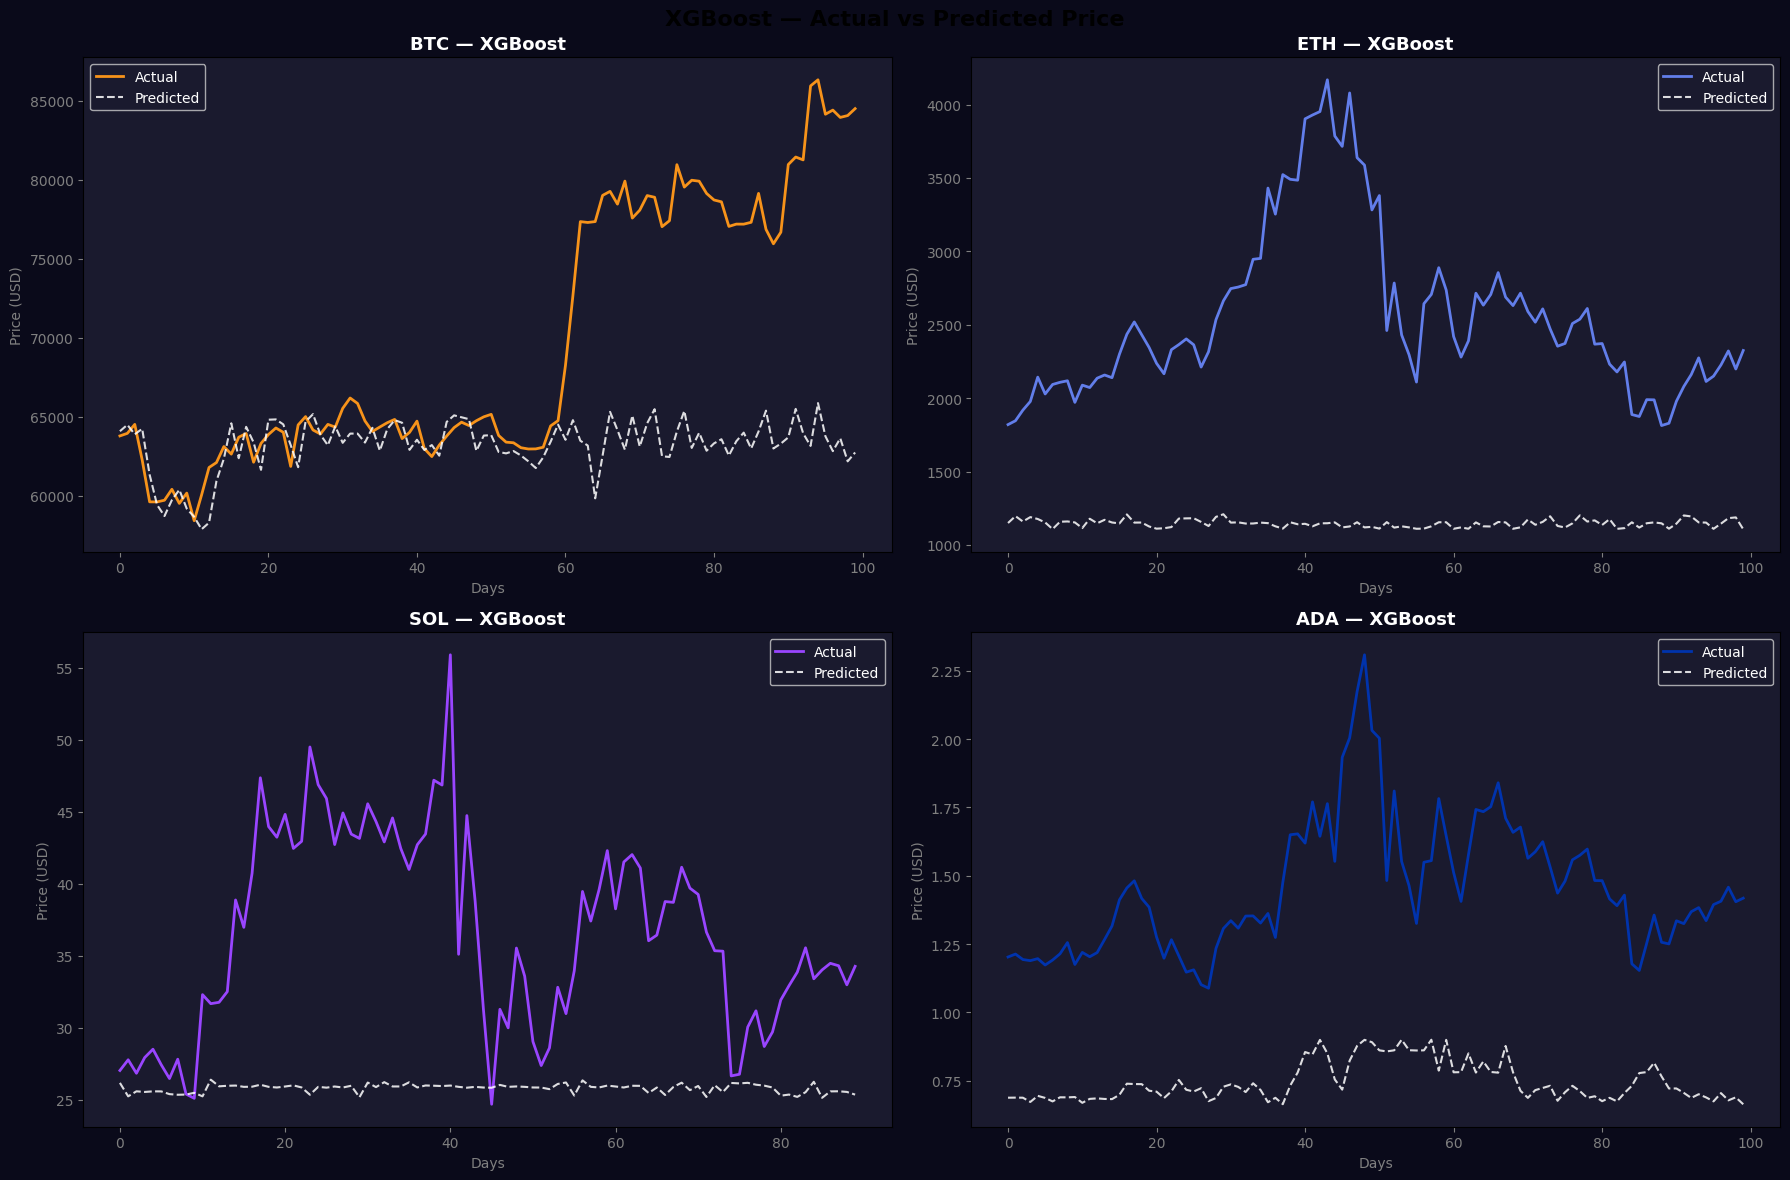

✅ Saved: xgboost_actual_vs_predicted.png
Download this PNG — you need it for PPT and report


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("XGBoost — Actual vs Predicted Price",
             fontsize=16, fontweight="bold")
fig.patch.set_facecolor("#0a0a1a")

colors = {
    "btc": "#f7931a",
    "eth": "#627eea",
    "sol": "#9945ff",
    "ada": "#0033ad"
}

for i, coin in enumerate(COINS):
    df    = load_coin(coin)
    _,test = time_split(df)

    model  = joblib.load(f"models/{coin}/xgboost.joblib")
    scaler = joblib.load(f"models/{coin}/scaler_xgboost.joblib")

    X_te  = scaler.transform(test[FEATURES])
    preds = model.predict(X_te)
    actual= test[TARGET].values

    # Show last 100 points for clarity
    n  = min(100, len(preds))
    ax = axes[i//2][i%2]
    ax.set_facecolor("#1a1a2e")

    ax.plot(actual[-n:], label="Actual",
            color=colors[coin], linewidth=2)
    ax.plot(preds[-n:],  label="Predicted",
            color="white", linestyle="--",
            linewidth=1.5, alpha=0.85)

    ax.set_title(f"{coin.upper()} — XGBoost",
                 fontsize=13, fontweight="bold",
                 color="white")
    ax.set_xlabel("Days", color="gray")
    ax.set_ylabel("Price (USD)", color="gray")
    ax.legend(facecolor="#1a1a2e",
              labelcolor="white")
    ax.tick_params(colors="gray")

plt.tight_layout()
plt.savefig("xgboost_actual_vs_predicted.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: xgboost_actual_vs_predicted.png")
print("Download this PNG — you need it for PPT and report")

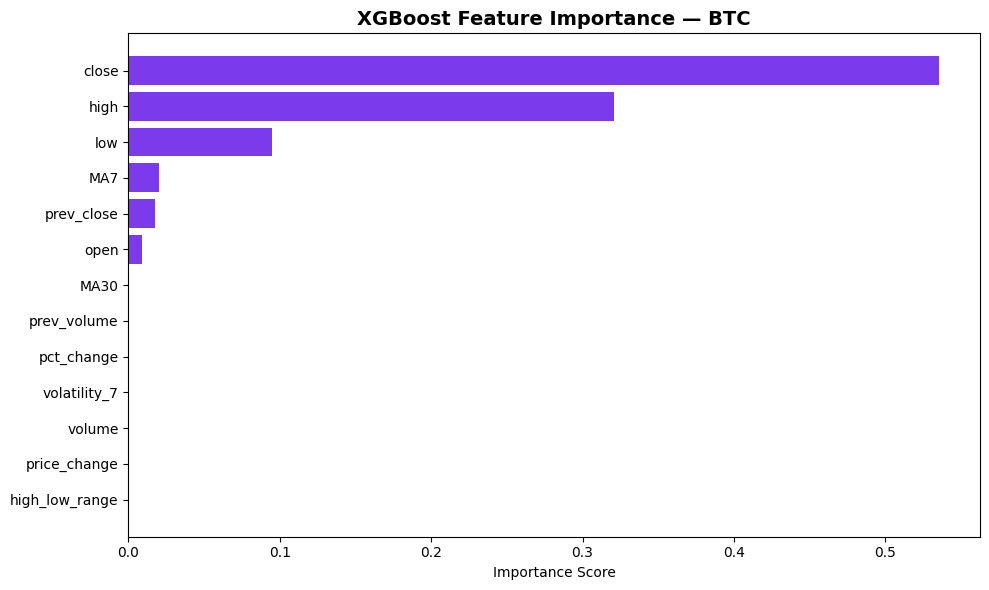

✅ Saved: feature_importance_btc.png
Download this PNG — needed for Model Metrics page and PPT


In [11]:
fi_btc = pd.read_csv("models/btc/feature_importance.csv")

plt.figure(figsize=(10, 6))
plt.barh(
    fi_btc["feature"],
    fi_btc["importance"],
    color="#7c3aed"
)
plt.title("XGBoost Feature Importance — BTC",
          fontsize=14, fontweight="bold")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("feature_importance_btc.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: feature_importance_btc.png")
print("Download this PNG — needed for Model Metrics page and PPT")

In [12]:
!pip install tensorflow -q
import tensorflow as tf
print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

SEQ_LEN = 30  # use last 30 days to predict next day

def make_sequences(X, y, seq_len):
    """
    Convert flat data into sequences.
    Each input = last 30 rows of features.
    Each output = next day's price.
    """
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i : i + seq_len])
        ys.append(y[i + seq_len])
    return np.array(Xs), np.array(ys)

def build_lstm_model(seq_len, n_features):
    """
    Build LSTM architecture:
    LSTM(128) → Dropout → LSTM(64) → Dropout → Dense(32) → Dense(1)
    """
    model = Sequential([
        LSTM(128,
             return_sequences=True,
             input_shape=(seq_len, n_features)),
        Dropout(0.2),
        LSTM(64,
             return_sequences=False),
        Dropout(0.2),
        Dense(32, activation="relu"),
        Dense(1)
    ])
    model.compile(
        optimizer="adam",
        loss="mse"
    )
    return model

print("✅ LSTM helper functions ready")
print(f"Sequence length: {SEQ_LEN} days")

✅ LSTM helper functions ready
Sequence length: 30 days


TRAINING LSTM — ALL 4 COINS
This will take 1.5 to 2 hours. Do not close Colab.

────────────────────────────────────────
Coin: BTC
BTC: 5,382 rows loaded
  Train: 4,305 rows (2012-01-02 → 2023-10-15)
  Test : 1,077 rows (2023-10-16 → 2026-09-26)
  Train sequences: (4275, 30, 13)
  Test  sequences: (1047, 30, 13)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 128)        │        72,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,225 (485.25 KB)

 Trainable params: 124,225 (485.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 13s 65ms/step - loss: 0.0030 - val_loss: 4.5200e-04
Epoch 2/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - loss: 0.0016 - val_loss: 3.9738e-04
Epoch 3/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - loss: 0.0013 - val_loss: 3.6174e-04
Epoch 4/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - loss: 9.5677e-04 - val_loss: 0.0037
Epoch 5/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - loss: 0.0012 - val_loss: 4.7217e-04
Epoch 6/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - loss: 7.5251e-04 - val_loss: 4.4087e-04
Epoch 7/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - loss: 7.6840e-04 - val_loss: 5.7751e-04
Epoch 8/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - loss: 9.0645e-04 - val_loss: 3.6427e-04
Epoch 9/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - loss: 6.6396e-04 - val_loss: 3.3822e-04
Epoch 10/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step - loss: 7.3703e-04 - val_loss: 3.6276e-04
Epoch 11/100
121/121 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - 

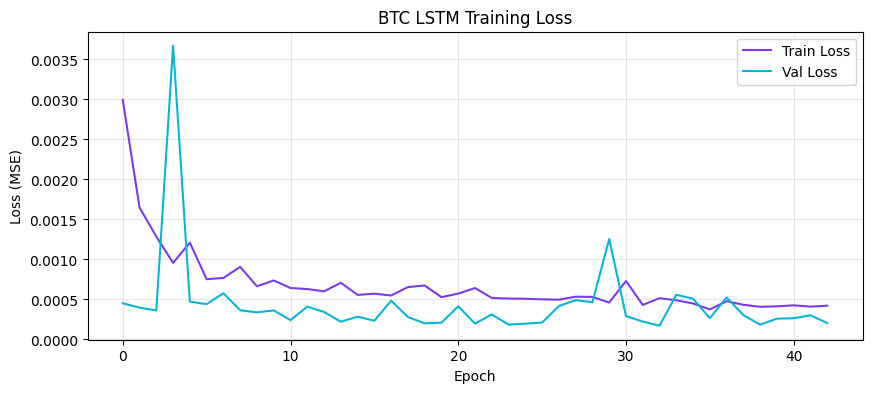

  ✅ BTC LSTM done

────────────────────────────────────────
Coin: ETH
ETH: 2,158 rows loaded
  Train: 1,726 rows (2015-08-09 → 2020-04-29)
  Test : 432 rows (2020-04-30 → 2021-07-05)
  Train sequences: (1696, 30, 13)
  Test  sequences: (402, 30, 13)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 30, 128)        │        72,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,225 (485.25 KB)

 Trainable params: 124,225 (485.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 89ms/step - loss: 0.0046 - val_loss: 0.0012
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 0.0024 - val_loss: 7.2906e-04
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 0.0017 - val_loss: 6.3351e-04
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0015 - val_loss: 3.5491e-04
Epoch 5/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - loss: 0.0017 - val_loss: 5.3756e-04
Epoch 6/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - loss: 0.0015 - val_loss: 5.0138e-04
Epoch 7/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0013 - val_loss: 4.6122e-04
Epoch 8/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 0.0015 - val_loss: 8.8190e-04
Epoch 9/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.0015 - val_loss: 9.6097e-04
Epoch 10/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - loss: 0.0011 - val_loss: 0.0015
Epoch 11/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0012 - val_loss: 7.9971e-04
Epoch 12/100
48/

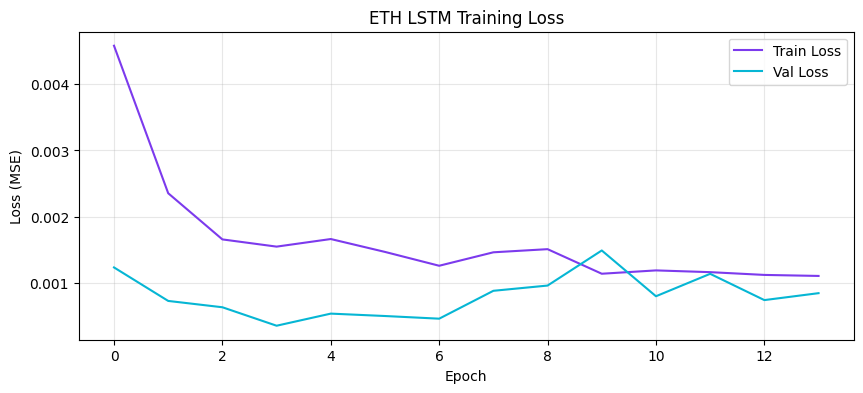

  ✅ ETH LSTM done

────────────────────────────────────────
Coin: SOL
SOL: 450 rows loaded
  Train: 360 rows (2020-04-12 → 2021-04-06)
  Test : 90 rows (2021-04-07 → 2021-07-05)
  Train sequences: (330, 30, 13)
  Test  sequences: (60, 30, 13)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 30, 128)        │        72,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,225 (485.25 KB)

 Trainable params: 124,225 (485.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - loss: 0.0057 - val_loss: 0.0115
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.0022 - val_loss: 0.0117
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.0029 - val_loss: 0.0112
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0017 - val_loss: 0.0190
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.0014 - val_loss: 0.0113
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0017 - val_loss: 0.0112
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.0013 - val_loss: 0.0114
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 9.2893e-04 - val_loss: 0.0151
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0016 - val_loss: 0.0141
Epoch 10/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.0010 - val_loss: 0.0122
Epoch 11/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - loss: 0.0012 - val_loss: 0.0155
Epoch 12/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms

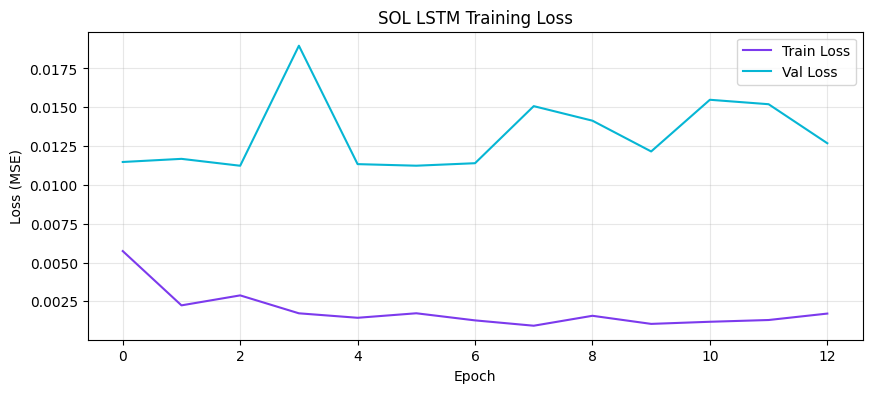

  ✅ SOL LSTM done

────────────────────────────────────────
Coin: ADA
ADA: 1,372 rows loaded
  Train: 1,097 rows (2017-10-03 → 2020-10-03)
  Test : 275 rows (2020-10-04 → 2021-07-05)
  Train sequences: (1067, 30, 13)
  Test  sequences: (245, 30, 13)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 30, 128)        │        72,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,225 (485.25 KB)

 Trainable params: 124,225 (485.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - loss: 0.0063 - val_loss: 1.3294e-04
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0033 - val_loss: 4.0449e-04
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - loss: 0.0023 - val_loss: 1.0653e-04
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - loss: 0.0023 - val_loss: 3.1925e-04
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0020 - val_loss: 2.6268e-04
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0020 - val_loss: 1.5845e-04
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.0019 - val_loss: 2.5531e-04
Epoch 8/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0019 - val_loss: 0.0011
Epoch 9/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.0016 - val_loss: 1.1298e-04
Epoch 10/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0016 - val_loss: 3.6611e-04
Epoch 11/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - loss: 0.0014 - val_loss: 6.5062e-04
Epoch 12/100


  === ADA — LSTM ===
  MAE  : $0.37
  RMSE : $0.48
  R²   : 0.3264
  ⚠️  Moderate fit — acceptable for crypto
  💾 Saved → models/ada/scaler_lstm_X.joblib
  💾 Saved → models/ada/scaler_lstm_y.joblib
  💾 Saved → models/ada/lstm.keras


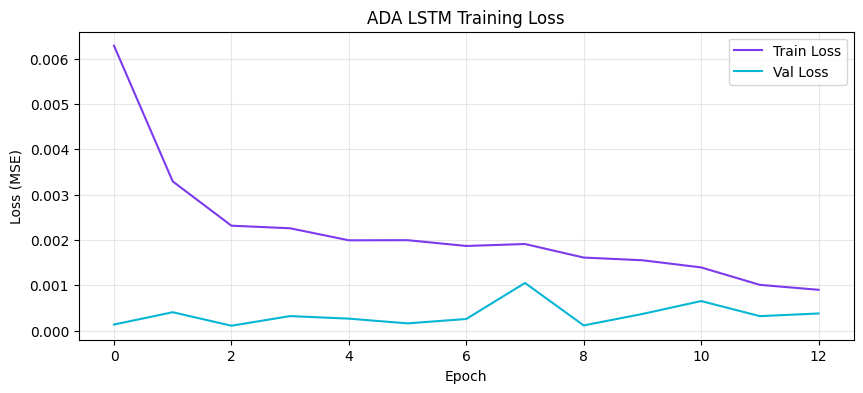

  ✅ ADA LSTM done

✅ LSTM training complete for all 4 coins

LSTM Results Summary:
coin model     mae     rmse      r2
 BTC  LSTM 8361.70 11083.80  0.7311
 ETH  LSTM  344.91   579.36  0.6399
 SOL  LSTM    7.82     9.38 -1.4015
 ADA  LSTM    0.37     0.48  0.3264


In [14]:
print("=" * 50)
print("TRAINING LSTM — ALL 4 COINS")
print("This will take 1.5 to 2 hours. Do not close Colab.")
print("=" * 50)

lstm_results = []

for coin in COINS:
    print(f"\n{'─'*40}")
    print(f"Coin: {coin.upper()}")

    df = load_coin(coin)
    train, test = time_split(df)

    # Two scalers:
    # scaler_X scales the input features
    # scaler_y scales the target (close price)
    # We need separate scalers so we can inverse transform predictions
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    # Scale X
    X_train_s = scaler_X.fit_transform(train[FEATURES])
    X_test_s  = scaler_X.transform(test[FEATURES])

    # Scale y (must be 2D for MinMaxScaler)
    y_train_s = scaler_y.fit_transform(
        train[[TARGET]]).flatten()
    y_test_s  = scaler_y.transform(
        test[[TARGET]]).flatten()

    # Create sequences
    X_tr_seq, y_tr_seq = make_sequences(
        X_train_s, y_train_s, SEQ_LEN)
    X_te_seq, y_te_seq = make_sequences(
        X_test_s,  y_test_s,  SEQ_LEN)

    print(f"  Train sequences: {X_tr_seq.shape}")
    print(f"  Test  sequences: {X_te_seq.shape}")

    # Build model
    model = build_lstm_model(SEQ_LEN, len(FEATURES))
    model.summary()

    # Early stopping prevents overfitting
    # Stops training when validation loss stops improving
    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1
    )

    # Train
    history = model.fit(
        X_tr_seq, y_tr_seq,
        epochs=100,
        batch_size=32,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=1
    )

    # Predict — output is scaled so we inverse transform
    preds_scaled = model.predict(
        X_te_seq, verbose=0).flatten()
    preds = scaler_y.inverse_transform(
        preds_scaled.reshape(-1, 1)).flatten()

    # Actual values — also inverse transform
    y_true = scaler_y.inverse_transform(
        y_te_seq.reshape(-1, 1)).flatten()

    # Evaluate
    result = evaluate(y_true, preds, "LSTM", coin)
    lstm_results.append(result)
    all_results.append(result)

    # Save
    os.makedirs(f"models/{coin}", exist_ok=True)
    model.save(f"models/{coin}/lstm.keras")
    save_artifact(scaler_X, coin, "scaler_lstm_X.joblib")
    save_artifact(scaler_y, coin, "scaler_lstm_y.joblib")
    print(f"  💾 Saved → models/{coin}/lstm.keras")

    # Plot training loss
    plt.figure(figsize=(10, 4))
    plt.plot(history.history["loss"],
             label="Train Loss", color="#7c3aed")
    plt.plot(history.history["val_loss"],
             label="Val Loss",   color="#06b6d4")
    plt.title(f"{coin.upper()} LSTM Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss (MSE)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(f"lstm_loss_{coin}.png",
                dpi=100, bbox_inches="tight")
    plt.show()
    print(f"  ✅ {coin.upper()} LSTM done")

print("\n✅ LSTM training complete for all 4 coins")
lstm_df = pd.DataFrame(lstm_results)
print("\nLSTM Results Summary:")
print(lstm_df.to_string(index=False))
lstm_df.to_csv("lstm_results.csv", index=False)

BTC: 5,382 rows loaded
  Train: 4,305 rows (2012-01-02 → 2023-10-15)
  Test : 1,077 rows (2023-10-16 → 2026-09-26)
ETH: 2,158 rows loaded
  Train: 1,726 rows (2015-08-09 → 2020-04-29)
  Test : 432 rows (2020-04-30 → 2021-07-05)
SOL: 450 rows loaded
  Train: 360 rows (2020-04-12 → 2021-04-06)
  Test : 90 rows (2021-04-07 → 2021-07-05)
ADA: 1,372 rows loaded
  Train: 1,097 rows (2017-10-03 → 2020-10-03)
  Test : 275 rows (2020-10-04 → 2021-07-05)


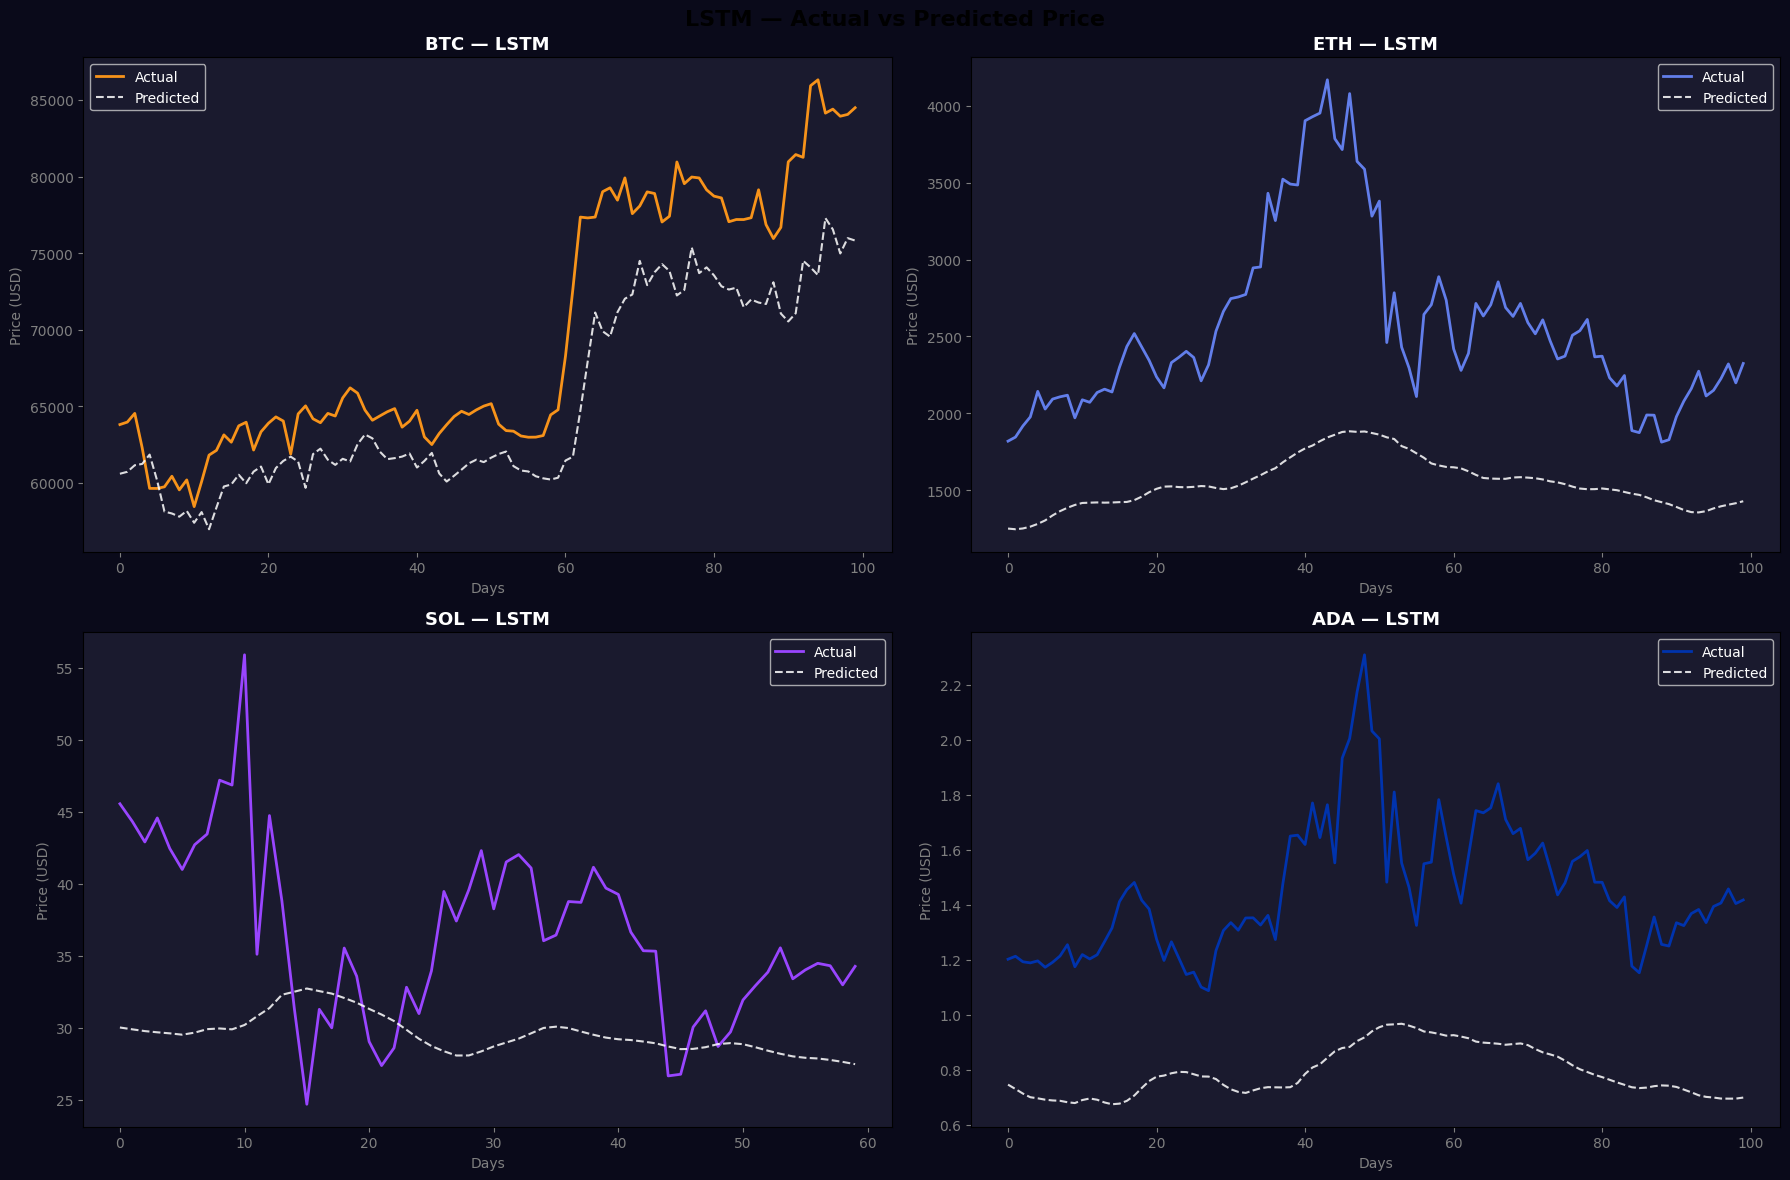

✅ Saved: lstm_actual_vs_predicted.png
Download this PNG


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("LSTM — Actual vs Predicted Price",
             fontsize=16, fontweight="bold")
fig.patch.set_facecolor("#0a0a1a")

for i, coin in enumerate(COINS):
    df = load_coin(coin)
    _, test = time_split(df)

    scaler_X = joblib.load(
        f"models/{coin}/scaler_lstm_X.joblib")
    scaler_y = joblib.load(
        f"models/{coin}/scaler_lstm_y.joblib")
    model    = tf.keras.models.load_model(
        f"models/{coin}/lstm.keras")

    X_te_s   = scaler_X.transform(test[FEATURES])
    y_te_s   = scaler_y.transform(test[[TARGET]]).flatten()
    Xseq, _  = make_sequences(X_te_s, y_te_s, SEQ_LEN)

    preds_s  = model.predict(Xseq, verbose=0).flatten()
    preds    = scaler_y.inverse_transform(
        preds_s.reshape(-1,1)).flatten()
    actual   = scaler_y.inverse_transform(
        y_te_s[SEQ_LEN:].reshape(-1,1)).flatten()

    n  = min(100, len(preds))
    ax = axes[i//2][i%2]
    ax.set_facecolor("#1a1a2e")
    ax.plot(actual[-n:], label="Actual",
            color=colors[coin], linewidth=2)
    ax.plot(preds[-n:],  label="Predicted",
            color="white", linestyle="--",
            linewidth=1.5, alpha=0.85)
    ax.set_title(f"{coin.upper()} — LSTM",
                 fontsize=13, fontweight="bold",
                 color="white")
    ax.set_xlabel("Days", color="gray")
    ax.set_ylabel("Price (USD)", color="gray")
    ax.legend(facecolor="#1a1a2e", labelcolor="white")
    ax.tick_params(colors="gray")

plt.tight_layout()
plt.savefig("lstm_actual_vs_predicted.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: lstm_actual_vs_predicted.png")
print("Download this PNG")